## Représentation graphique des résultats

Le geofile utilisé pour les fonds de carte est issu du projet GIT réalisé par gregoiredavid

In [ ]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import box
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Markdown
display(Markdown("""## Représentation graphique des résultats

Le geofile utilisé pour les fonds de carte est issu du projet GIT réalisé par Gregoire David."""))


url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/communes.geojson"
communes = gpd.read_file(url)


Les variables et fonctions suivantes seront communes à toutes les représentations graphiques

In [3]:
BLOC_GAUCHE_ECOLO = [
    'LVECE', # Europe Ecologie-Les Verts
    'LVEC',	#Europe Ecologie-Les Verts
    'LECO',  # Ecologiste
    'LUG',   # Union de la Gauche
    'LDVG',   # Divers Gauche
    'LSOC',	#Parti socialiste
    'LPG'	#Liste du Parti de Gauche
]

BLOC_EXT_GAUCHE = [
    'LEXG',	#Extrême gauche
    'LCOM',	#Parti communiste français
    'LFI',	#La France insoumise
    'LRDG',	#Parti radical de gauche
    'LFG' #Liste Front de Gauche
]

BLOC_CENTRE = [
    'LREM',#	La République en marche
    'LMDM',#	Modem
    'LUC',#	Union du centre
    'LDVC'#	Divers centre

]

BLOC_DROITE =[
    'LLR',#	Les Républicains
    'LUD',#	Union de la droite
    'LDVD',#	Divers droite
    'LUDI',#	Liste Union Démocrates et Indépendants
    'LUMP'#	Liste Union pour un Mouvement Populaire
]

BLOC_EXT_DROITE = [
    'LDLF',#	Debout la France
    'LRN',#	Rassemblement National
    'LEXD',#	Extrême droite
    'LFN'#	Liste Front National
]

BLOC_AUTRE = [
    'LDIV',#	Divers
    'LREG',#	Régionaliste
    'LGJ',#	Gilets jaunes
    'LNC'#	Non Communiqué
]


colors = {
    "Gauche Écolo": "green",
    "Extrême Gauche": "darkred",
    "Centre": "gold",
    "Droite": "dodgerblue",
    "Extrême Droite": "midnightblue",
    "Autre": "lightgray"
}   

In [4]:
def assign_bloc(nuance):
    if pd.isna(nuance):
        return "Autre"
    elif nuance in BLOC_GAUCHE_ECOLO:
        return "Gauche Écolo"
    elif nuance in BLOC_EXT_GAUCHE:
        return "Extrême Gauche"
    elif nuance in BLOC_CENTRE:
        return "Centre"
    elif nuance in BLOC_DROITE:
        return "Droite"
    elif nuance in BLOC_EXT_DROITE:
        return "Extrême Droite"
    elif nuance in BLOC_AUTRE:
        return "Autre"
    else:
        return "Autre"

## Carte pour des résultats pour les élections 2020

In [ ]:
elec_2020 = pd.read_csv('/home/onyxia/work/Python-project/Data/raw_elections/elec_2020_all.csv')
elec_2020 = elec_2020[elec_2020["winner"] == "yes"]
elec_2020["Code commune"] = elec_2020["Code commune"].astype(str)

elec_2020['Bloc nuance'] = elec_2020['Code Nuance'].apply(assign_bloc)

/tmp/ipykernel_4170/1865855501.py:8: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  merged_2020.plot(column="Bloc nuance",


<Axes: >

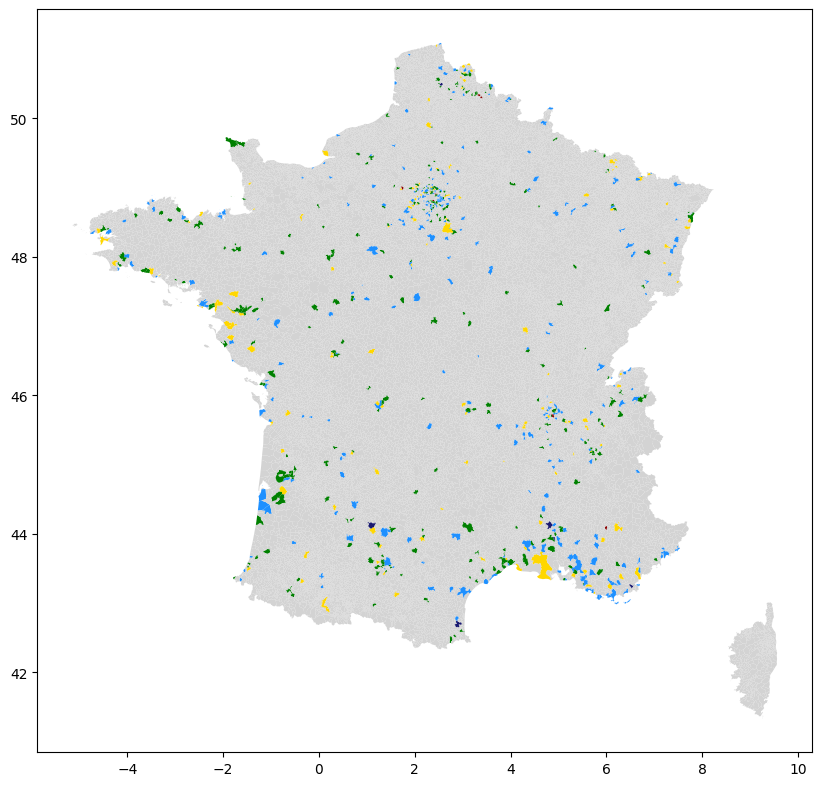

In [ ]:
merged_2020 = communes.merge(elec_2020,
                        left_on="code", 
                        right_on="Code commune",
                        how="left")  

merged_2020['Bloc nuance'] = merged_2020['Bloc nuance'].fillna('Autre')

#merged_2020.plot(column="Bloc nuance",
#            categorical=True,
#            legend=True,
#            color=merged_2020['Bloc nuance'].map(colors),
#            figsize=(10, 10)) 


bbox = gpd.GeoDataFrame(
    geometry=[box(2.0, 42.2, 7.8, 44.2)],
    crs="EPSG:4326"
).to_crs(merged_2020.crs)
merged_med = merged_2020[merged_2020.intersects(bbox.geometry[0])]
merged_med["color"] = merged_med["Bloc nuance"].map(colors)

fig, ax = plt.subplots(figsize=(10, 8))
merged_med.plot(color=merged_med["color"], ax=ax)

ax.set_title("Résultat Election 2020")
plt.show()

## Carte pour des résultats pour les élections 2014

/tmp/ipykernel_4170/1490220872.py:13: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  merged_2014.plot(column="Bloc nuance",


<Axes: >

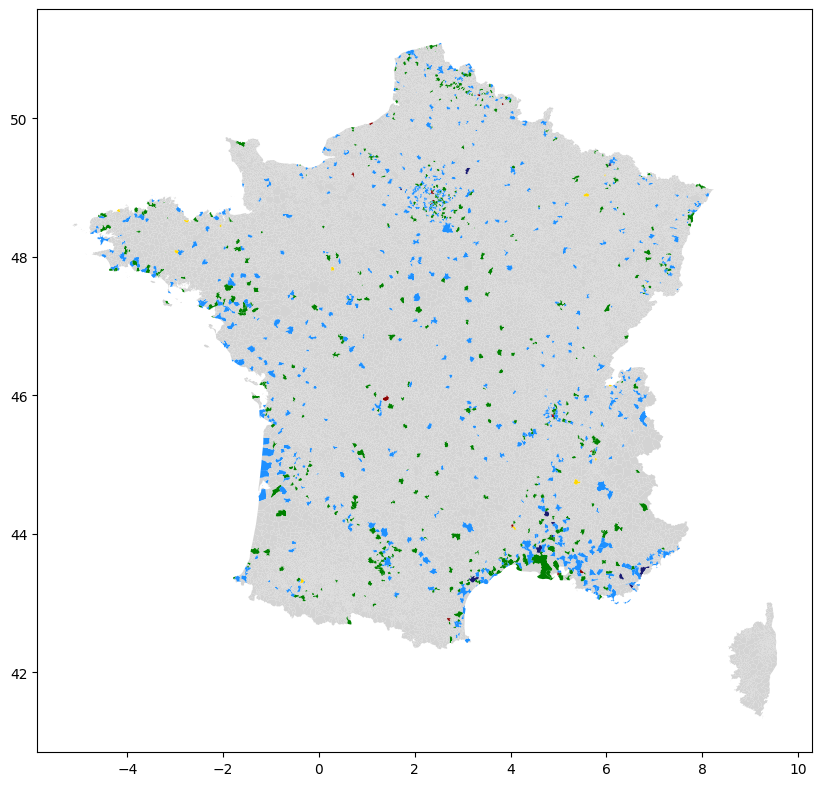

In [ ]:
elec_2014 = pd.read_csv('/home/onyxia/work/Python-project/Data/raw_elections/elec_2014_all.csv')
elec_2014 = elec_2014[elec_2014["winner"] == "yes"]
elec_2014["Code commune"] = elec_2014["Code commune"].astype(str)

elec_2014['Bloc nuance'] = elec_2014['Code Nuance'].apply(assign_bloc)

merged_2014 = communes.merge(elec_2014,
                        left_on="code", 
                        right_on="Code commune",
                        how="left")  

merged_2014['Bloc nuance'] = merged_2014['Bloc nuance'].fillna('Autre')

#merged_2014.plot(column="Bloc nuance",
#            categorical=True,
#            legend=True,
#            color=merged_2014['Bloc nuance'].map(colors),
#            figsize=(10, 10)) 


bbox = gpd.GeoDataFrame(
    geometry=[box(2.0, 42.2, 7.8, 44.2)],
    crs="EPSG:4326"
).to_crs(merged_2014.crs)
merged_med = merged_2014[merged_2014.intersects(bbox.geometry[0])]
merged_med["color"] = merged_med["Bloc nuance"].map(colors)

fig, ax = plt.subplots(figsize=(10, 8))
merged_med.plot(color=merged_med["color"], ax=ax)

ax.set_title("Résultat Election 2014")
plt.show()

In [ ]:
display(Markdown("""
## Représentation graphique des variables explicatives utiles à notre modélisation (pour les élections municipales de 2014 et 2020)

Nous nous intéressons notamment :
 * au revenu médian par commune (colonne MEDXX)
 * à la population communale (colonne PXX_POP)
 * à la part de cadres dans la population (colonne CXX_POP15P_SC3)
 * au nombre de diplomés du supérieur dans chaque commune (colonne P14_NSCOL15P_SUPXX)"""))


NameError: name 'Markdown' is not defined

## Représentation graphique des variables explicatives liées à notre modélisation

Dans notre modèle de régression, nous utilisons des données XXX produites annuellement par l'INSEE au cours de leur différentes enquêtes.
Nous nous intéressons notamment :
 * au revenu médian par commune (colonne MEDXX)
 * à la population communale (colonne PXX_POP)
 * à la part de cadres dans la population (colonne CXX_POP15P_SC3)
 * au nombre de diplomés du supérieur dans chaque commune (colonne P14_NSCOL15P_SUPXX)

In [26]:
fusion_data = pd.read_csv(
    '/home/onyxia/work/Python-project/Data/data_pour_nos_codes/bases_merged/fusion_data_insee.csv',
    header=0
)

fusion_data = fusion_data[fusion_data["MED19"] != "s"]
fusion_data["MED19"]= pd.to_numeric(fusion_data["MED19"])
fusion_data.head(5)


,COM,P14_POP,C14_POP15P_CS3,P14_NSCOL15P_SUP,MED13,P20_POP,C20_POP15P_CS3,P20_NSCOL15P_SUP2,P20_NSCOL15P_SUP34,P20_NSCOL15P_SUP5,MED19
0,01001,767.0,75.000000,141.000000,22130.000000,806.0,61.774238,83.435537,58.938581,38.706320,23970.0
1,01002,239.0,14.753086,59.995885,23213.000000,262.0,18.283656,28.977294,27.590460,23.934686,23640.0
2,01004,14022.0,743.288479,2326.327150,19554.000000,14288.0,804.651500,1345.650547,800.138921,732.117886,20510.0
3,01005,1627.0,105.518839,281.383570,22387.619048,1782.0,115.000000,186.000000,104.000000,87.000000,24050.0
5,01007,2570.0,195.000000,497.000000,21650.666667,2827.0,211.204367,291.197842,180.816511,149.356733,23380.0


In [ ]:
display(Markdown("""## Revenu médian par commune"""))

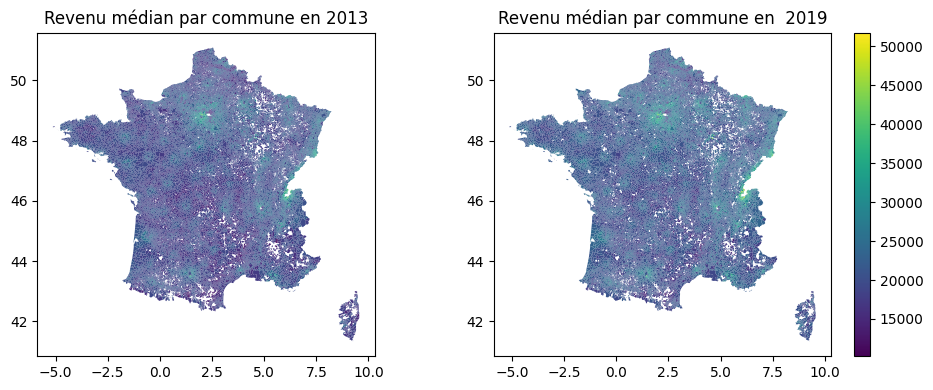

In [ ]:
carte_med = communes.merge(fusion_data[['COM', 'MED13', 'MED19']],
                        left_on="code", 
                        right_on="COM",
                        how="left")
                        
vmin = min(carte_med["MED13"].min(), carte_med["MED19"].min())
vmax = max(carte_med["MED13"].max(), carte_med["MED19"].max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

carte_med.plot(
    column="MED13",
    ax=axes[0],
    vmin=vmin,
    vmax=vmax,
    legend=False
)
axes[0].set_title("Revenu médian par commune en 2013")

carte_med.plot(
    column="MED19",
    ax=axes[1],
        vmin=vmin,
    vmax=vmax,
    legend=True
)
axes[1].set_title("Revenu médian par commune en 2019")


plt.tight_layout()
plt.show()

In [ ]:
display(Markdown("""Le revenue médian est significativement plus élevé dans les communes proches de Paris et de la frontière avec la Suisse. Aussi, la proximité avec une grande métropole à un effet positif, qui est d'autant plus marqué en 2019.

Au global, on observe aussi une augmentation générale du revenu médian à travers le pays entre 2013 et 2019."""))

In [ ]:
display(Markdown("""## Population communale"""))

/opt/python/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


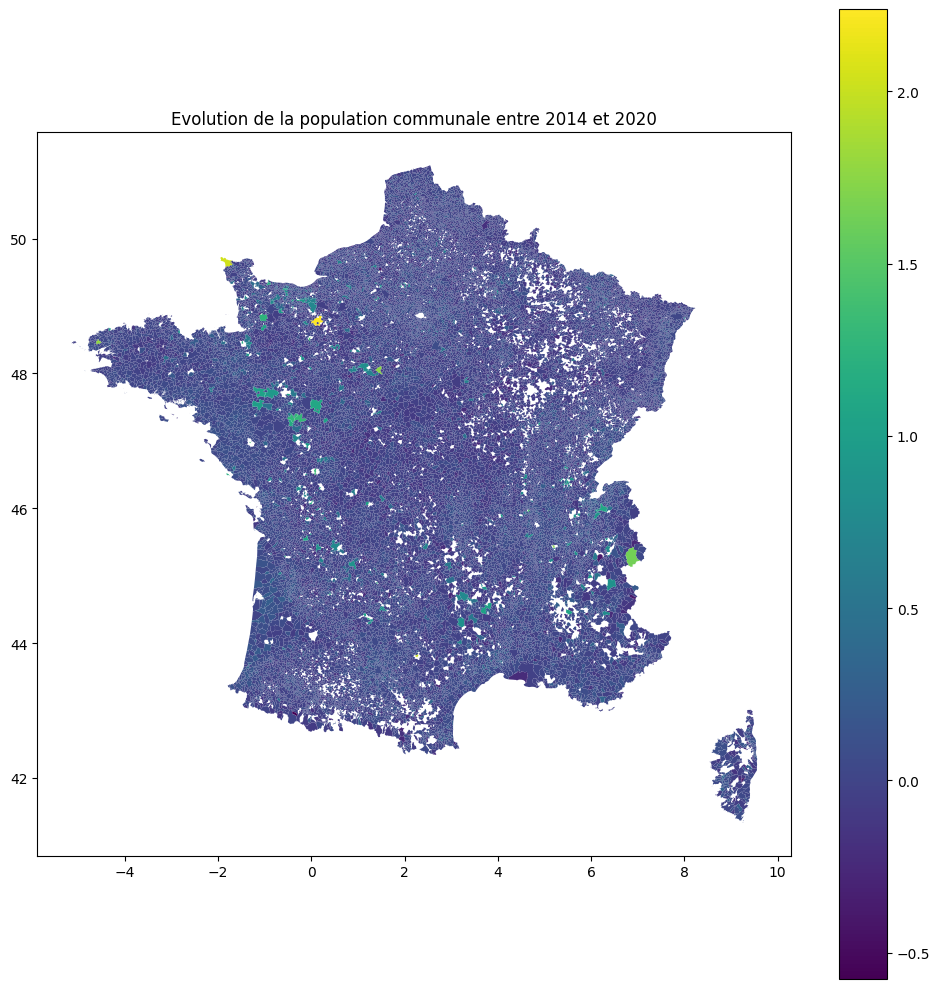

In [ ]:
carte_pop = communes.merge(fusion_data[['COM','P14_POP', 'P20_POP']],
                        left_on="code", 
                        right_on="COM",
                        how="left")

carte_pop['ln_diff'] = np.log(carte_pop['P20_POP']) - np.log(carte_pop['P14_POP'])

                        
vmin = carte_pop["ln_diff"].min()
vmax = carte_pop["ln_diff"].max()

carte_pop.plot(
    column="ln_diff",
    vmin=vmin,
    vmax=vmax,
    legend=True,figsize=(10, 10)
)

plt.title("Evolution de la population communale entre 2014 et 2020 (échelle log)") 
plt.tight_layout()
plt.show()

In [ ]:
display(Markdown("""
Dans une grande majorité de communes, la population est restée plutôt stable entre 2014 et 2020. Quelques communes échappent à cette règle et ont subit une forte augmentation de leur nombre d'habitant sur la période : elles se retrouvent notamment en Normandie, dans le pays de Loire, en Savoie ainsi que dans le sud et l'ouest du Massif Central.

## Part de diplomés du supérieur par communes"""))

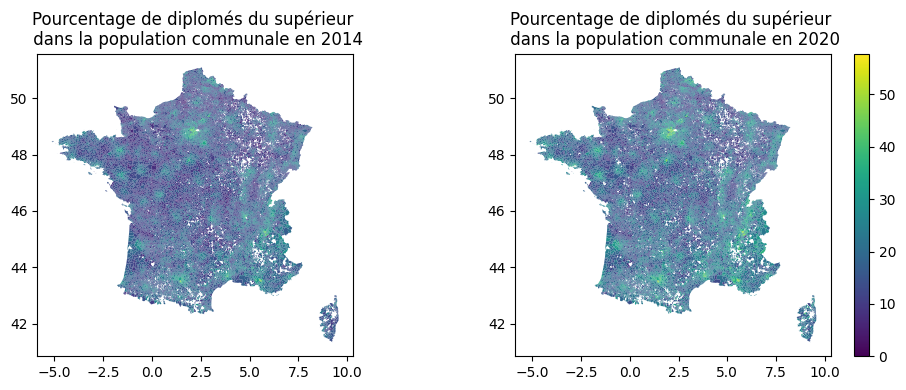

In [136]:
carte_sup = communes.merge(fusion_data[['COM', 'P14_NSCOL15P_SUP', 'P20_NSCOL15P_SUP2', 'P20_NSCOL15P_SUP34','P20_NSCOL15P_SUP5','P14_POP', 'P20_POP']],
                        left_on="code", 
                        right_on="COM",
                        how="left")

carte_sup['P20_NSCOL15P_SUP'] = carte_sup['P20_NSCOL15P_SUP2'] + carte_sup['P20_NSCOL15P_SUP34'] + carte_sup['P20_NSCOL15P_SUP5']
carte_sup['2014_ratio'] = 100 * carte_sup['P14_NSCOL15P_SUP'] / carte_sup['P14_POP']
carte_sup['2020_ratio'] = 100* carte_sup['P20_NSCOL15P_SUP'] / carte_sup['P20_POP']

vmin = min(carte_sup["2014_ratio"].min(), carte_sup["2020_ratio"].min())
vmax = max(carte_sup["2014_ratio"].max(), carte_sup["2020_ratio"].max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

carte_sup.plot(
    column="2014_ratio",
    ax=axes[0],
    vmin=vmin,
    vmax=vmax,
    legend=False
)
axes[0].set_title("Pourcentage de diplomés du supérieur \n dans la population communale en 2014")

carte_sup.plot(
    column="2020_ratio",
    ax=axes[1],
    vmin=vmin,
    vmax=vmax,
    legend=True
)
axes[1].set_title("Pourcentage de diplomés du supérieur \n dans la population communale en 2020")


plt.tight_layout()
plt.show()

In [ ]:
display(Markdown("""Comme attendu, le pourcentage de diplômés du supérieur est sensiblement plus important dans les banlieues de grandes métropoles comme Paris, Lyon, Toulouse, Marseille... Au niveau national, on constate une hausse globale de la part de diplômés du supérieur dans la population.

Par ailleurs, l'évolution de la part de diplômés du supérieur sur la période 2014-2020 est très variable enter les communes.

On observe dans les graphes suivants une augmentation au global plus marqué pour la Bretagne, la région parisienne élargie et la vallée du Rhône.
Au contraire, les diplômés se font plus rares dans les communes reculées du grand Est, de la diagonale du vide et des Pyrénées.
"""))

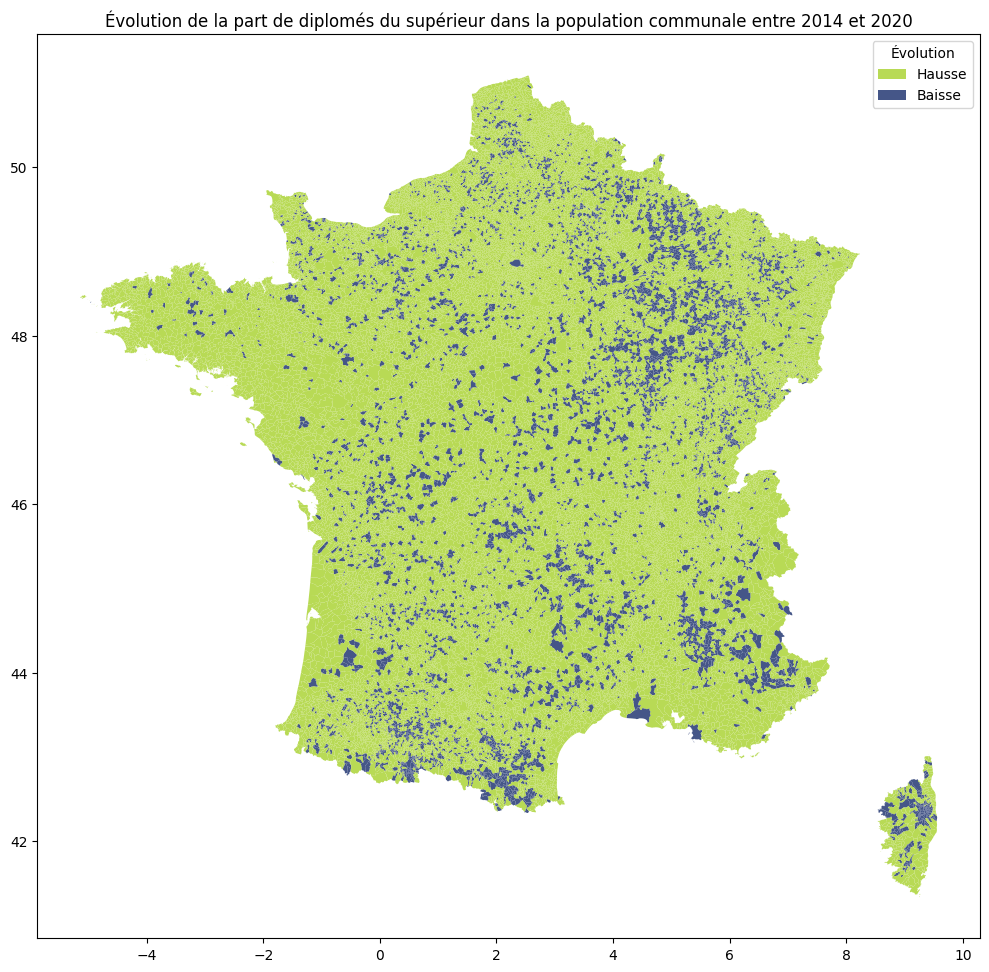

In [ ]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

carte_sup['evol'] = np.where(carte_sup["2020_ratio"] - carte_sup["2014_ratio"] > 0, 1, -1)
cmap = ListedColormap(["#455688", "#b8da55"])

ax = carte_sup.plot(
    column="evol",
    categorical=True,
    legend=True,
    cmap=cmap,
    figsize=(10, 10)
)

legend_elements = [
    Patch(facecolor="#b8da55", label="Hausse"),
    Patch(facecolor="#455688", label="Baisse")
]

ax.legend(handles=legend_elements, title="Évolution")
plt.title("Évolution de la part de diplomés du supérieur \n dans la population communale entre 2014 et 2020")
plt.tight_layout()
plt.show()

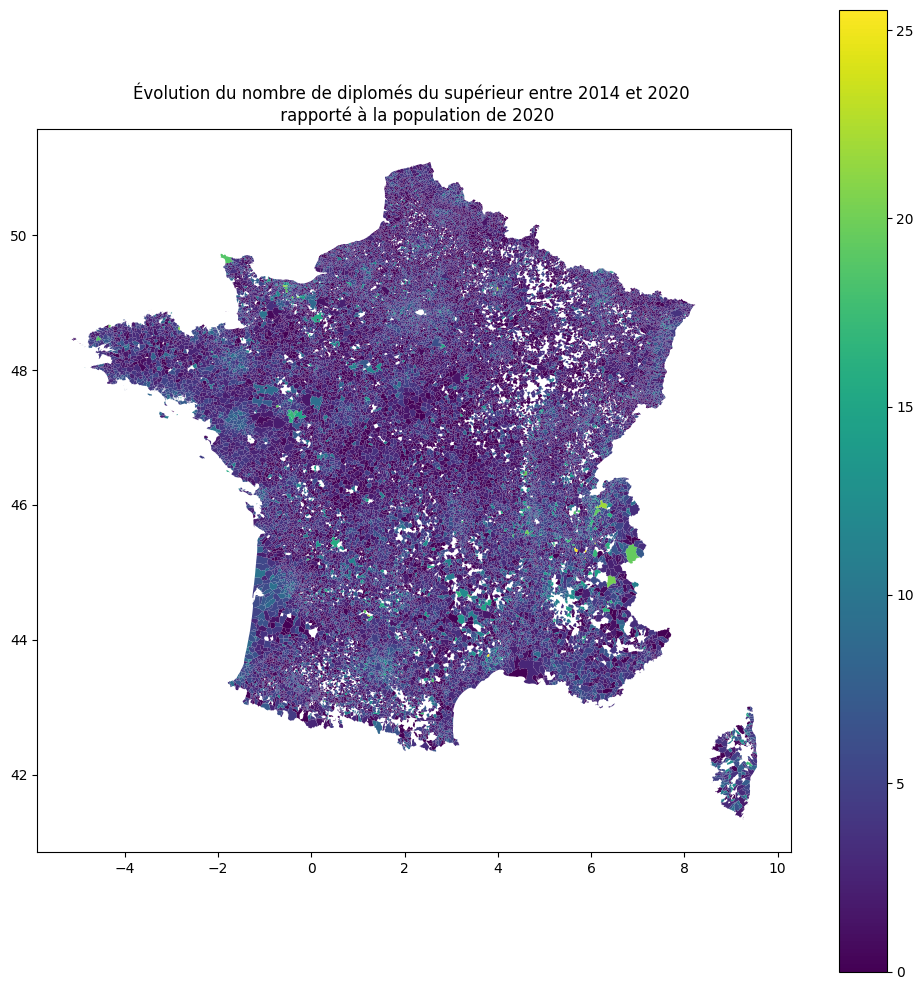

In [138]:
carte_sup['diff'] = 100*(carte_sup['P20_NSCOL15P_SUP'] - carte_sup['P14_NSCOL15P_SUP'])/carte_sup['P20_POP']

carte_sup.plot(
    column="diff",
    vmin=0,
    vmax=carte_sup["diff"].max(),
    legend=True,
    figsize=(10, 10)
)

plt.title("Évolution du nombre de diplomés du supérieur entre 2014 et 2020 \n rapporté à la population de 2020")
plt.tight_layout()
plt.show()